# GREENLY - Raw Dataset Exploration

Explores the six real public datasets before any cleaning/engineering. See `../DATASETS.md` for full source citations and licensing.

Run `python ../scripts/download_datasets.py` first if `../data/raw/` is empty.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
RAW = Path('..') / 'data' / 'raw'
pd.set_option('display.max_columns', 20)

## 1. EPA `vehicles.csv` -> Carbon/Transport model
Every EPA-tested vehicle model, 1984-present. Real tailpipe CO2 (g/mile), fuel economy, vehicle class.

In [2]:
vehicles = pd.read_csv(RAW / 'vehicles.csv', low_memory=False)
print(f'{len(vehicles):,} vehicle records, {vehicles.shape[1]} columns')
vehicles[['year', 'make', 'model', 'VClass', 'fuelType1', 'comb08', 'co2TailpipeGpm']].head()

49,995 vehicle records, 84 columns


,year,make,model,VClass,fuelType1,comb08,co2TailpipeGpm
0,1985,Alfa Romeo,Spider Veloce 2000,Two Seaters,Regular Gasoline,21,423.190476
1,1985,Ferrari,Testarossa,Two Seaters,Regular Gasoline,11,807.909091
2,1985,Dodge,Charger,Subcompact Cars,Regular Gasoline,27,329.148148
3,1985,Dodge,B150/B250 Wagon 2WD,Vans,Regular Gasoline,11,807.909091
4,1993,Subaru,Legacy AWD Turbo,Compact Cars,Premium Gasoline,19,467.736842


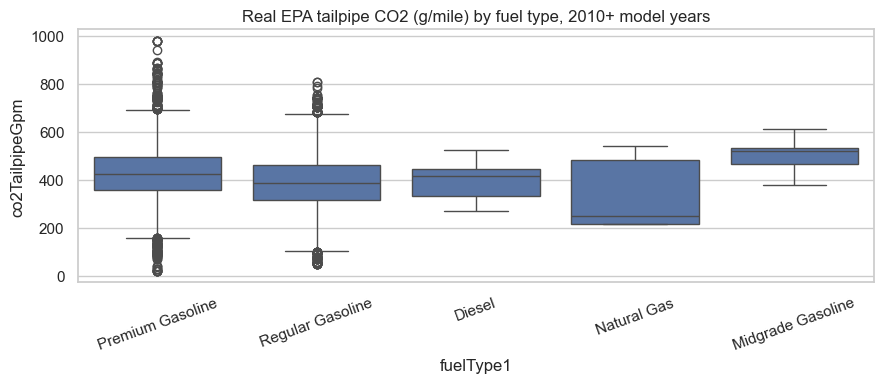

In [3]:
valid = vehicles[(vehicles['co2TailpipeGpm'] > 0) & (vehicles['year'] >= 2010)]
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=valid, x='fuelType1', y='co2TailpipeGpm', ax=ax)
ax.set_title('Real EPA tailpipe CO2 (g/mile) by fuel type, 2010+ model years')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

## 2. UCI Appliances Energy Prediction -> Energy/Electronics model
10-minute-interval whole-house appliance energy (Wh) for one real low-energy house, ~4.5 months.

19,735 readings from 2016-01-11 17:00:00 to 2016-05-27 18:00:00


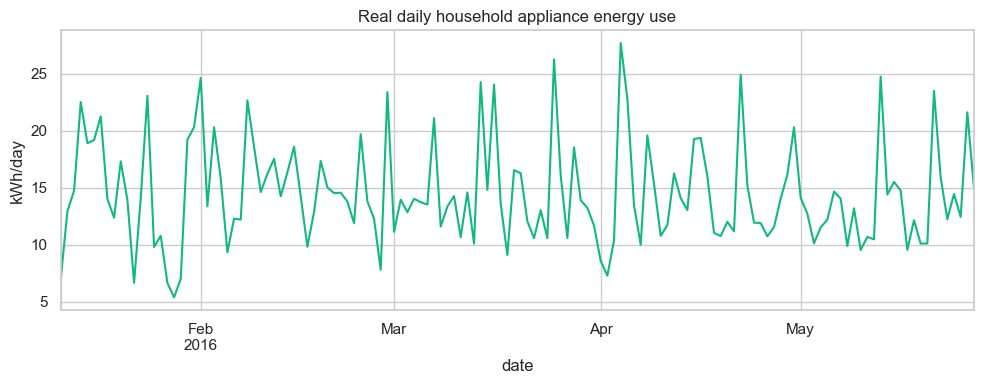

In [4]:
energy = pd.read_csv(RAW / 'energydata_complete.csv', parse_dates=['date'])
print(f'{len(energy):,} readings from {energy.date.min()} to {energy.date.max()}')
daily = energy.set_index('date')[['Appliances', 'lights']].resample('D').sum()
fig, ax = plt.subplots(figsize=(10, 4))
(daily.sum(axis=1) / 1000).plot(ax=ax, color='#10b981')
ax.set_ylabel('kWh/day'); ax.set_title('Real daily household appliance energy use')
plt.tight_layout(); plt.show()

## 3. Our World in Data / Poore & Nemecek (2018) -> Food model
GHG emissions per kg for 40 food products, meta-analysis of 38,700 farms across 119 countries.

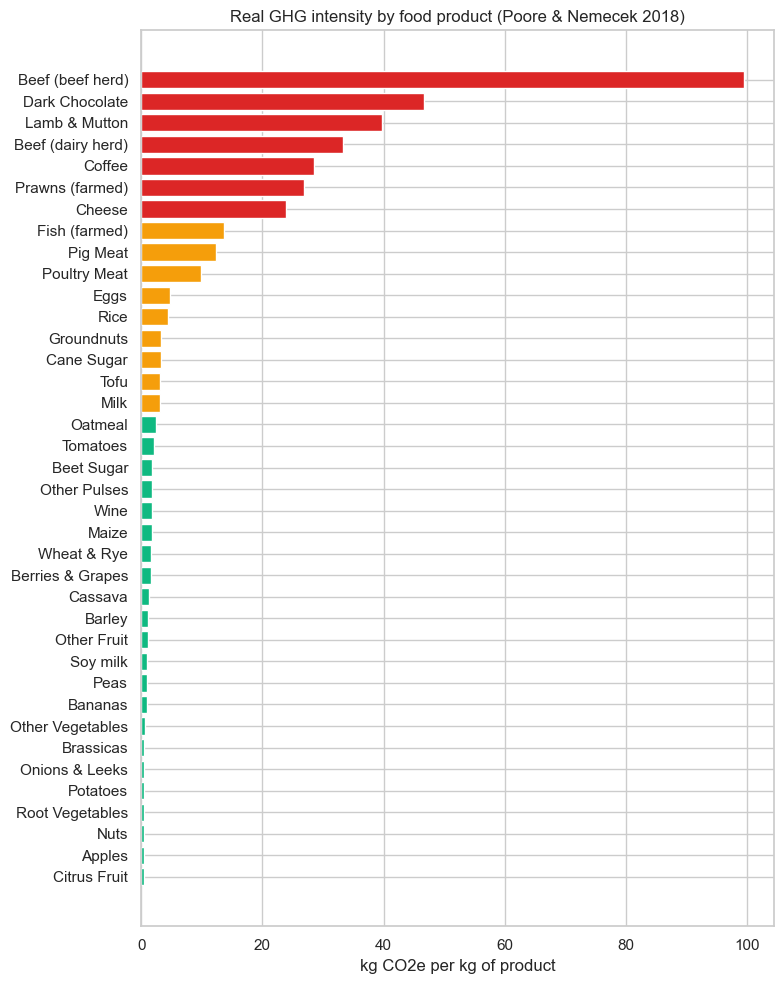

In [5]:
food_ghg = pd.read_csv(RAW / 'ghg-per-kg-poore.csv').sort_values('Greenhouse gas emissions per kilogram')
fig, ax = plt.subplots(figsize=(8, 10))
colors = ['#dc2626' if x > 20 else '#f59e0b' if x > 3 else '#10b981' for x in food_ghg['Greenhouse gas emissions per kilogram']]
ax.barh(food_ghg['Entity'], food_ghg['Greenhouse gas emissions per kilogram'], color=colors)
ax.set_xlabel('kg CO2e per kg of product'); ax.set_title('Real GHG intensity by food product (Poore & Nemecek 2018)')
plt.tight_layout(); plt.show()

## 4. OWID Municipal Waste -> Waste model
Real country-year waste collection rates, used to sample a realistic `recycledPercent` distribution.

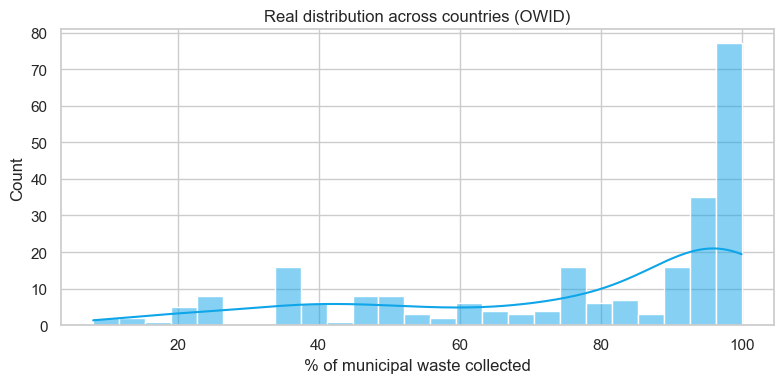

count    239.000000
mean      76.714498
std       26.421596
min        8.000000
25%       55.500000
50%       90.747826
75%       98.221610
max      100.000000
Name: Share of total municipal solid waste collected, dtype: float64


In [6]:
waste = pd.read_csv(RAW / 'share-waste-collected.csv')
col = waste.columns[-1]
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(waste[col].dropna(), bins=25, kde=True, ax=ax, color='#0ea5e9')
ax.set_xlabel('% of municipal waste collected'); ax.set_title('Real distribution across countries (OWID)')
plt.tight_layout(); plt.show()
print(waste[col].describe())

## Takeaway
All four sources above are real, publicly published, unmodified at this stage. The next notebook (`02_dataset_preparation.ipynb`) shows how they're turned into trainable per-category datasets.